**STEP 1: IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**STEP 2: LOAD DATA**

In [4]:
df = pd.read_csv("retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


**STEP 3: DATA CLEANING**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [9]:
df = df.dropna()

**STEP 4: FEATURE ENGINEERING**

In [10]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

**STEP 5: EXPLORATORY DATA ANALYSIS (EDA)**

📈 1. SALES OVER TIME









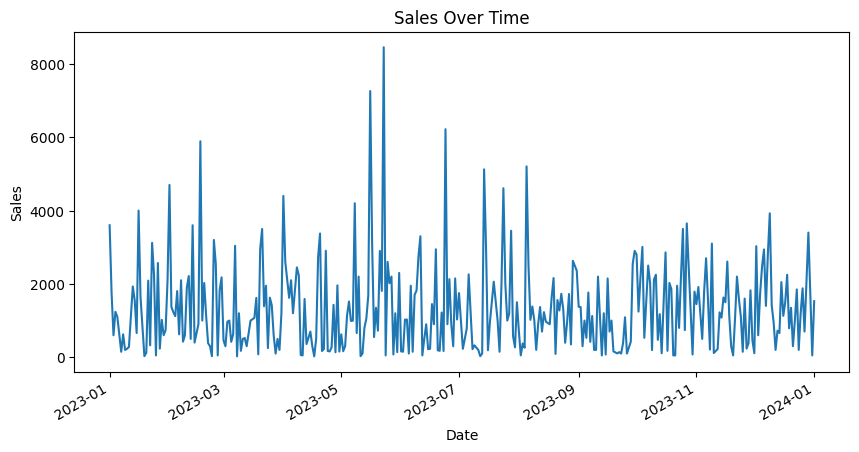

In [11]:
sales_trend = df.groupby('Date')['Total Amount'].sum()

plt.figure(figsize=(10,5))
sales_trend.plot()
plt.title("Sales Over Time")
plt.ylabel("Sales")
plt.show()

📊 2. SALES BY CATEGORY

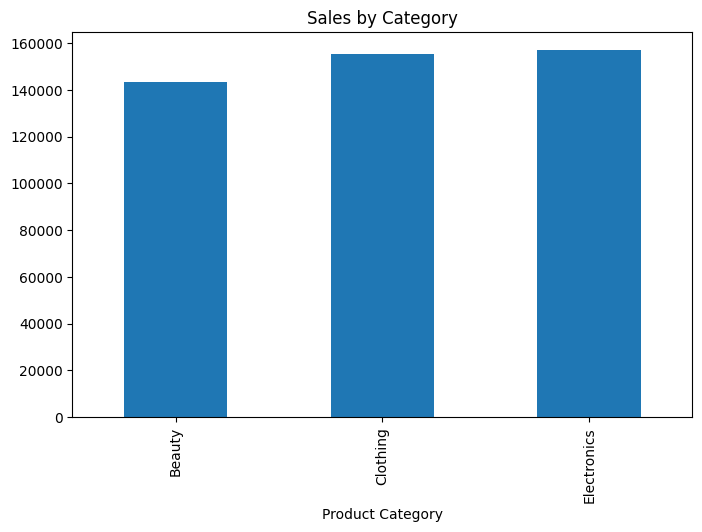

In [12]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

👥 3. SALES BY GENDER

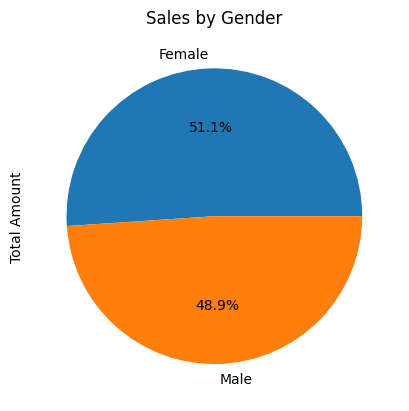

In [13]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

gender_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales by Gender")
plt.show()

🔥 4. AGE VS SALES

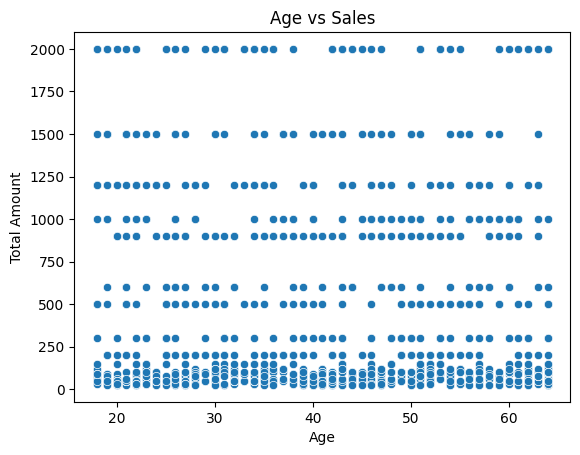

In [14]:
sns.scatterplot(x='Age', y='Total Amount', data=df)
plt.title("Age vs Sales")
plt.show()

**STEP 6: PREPARE DATA FOR FORECASTING**

In [15]:
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

daily_sales = df['Total Amount'].resample('D').sum()

**STEP 7: FORECASTING (ARIMA MODEL 🚀)**

In [16]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(daily_sales, order=(5,1,0))
model_fit = model.fit()

forecast = model_fit.forecast(steps=30)

**STEP 8: VISUALIZE FORECAST**

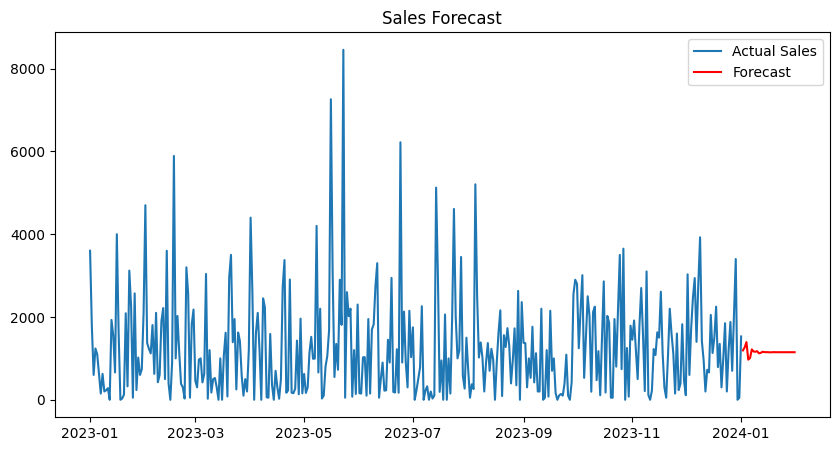

In [17]:
plt.figure(figsize=(10,5))

plt.plot(daily_sales, label='Actual Sales')
plt.plot(forecast, label='Forecast', color='red')

plt.legend()
plt.title("Sales Forecast")
plt.show()

**STEP 9: INTERACTIVE GRAPH (VERY IMPORTANT ⭐)**

In [18]:
import plotly.express as px

fig = px.line(daily_sales, title="Interactive Sales Trend")
fig.show()

🏆 Top Category

In [19]:
df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

,Total Amount
Product Category,
Electronics,156905
Clothing,155580
Beauty,143515


📅 Monthly Sales

/tmp/ipykernel_22327/3777295344.py:1: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



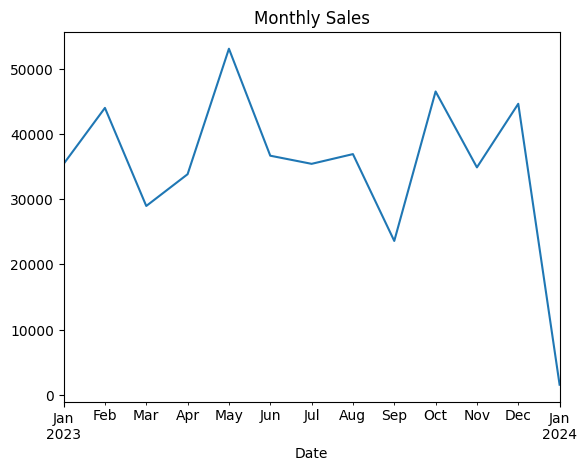

In [20]:
monthly_sales = daily_sales.resample('M').sum()
monthly_sales.plot()
plt.title("Monthly Sales")
plt.show()